In [1]:
from src.utils.matrix_ops import keep_S_in, kl_divergence
import src.algorithms.projected_subgradient as ps

In [2]:
import torch

$$M^{*}(x,y)=\frac{\pi (y) M(y,x)}{\pi(x)}.$$

In [3]:
def pi_adjoint(M: torch.Tensor, pi: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """
    pi-adjoint of M:
        M^*(x,y) = pi(y) M(y,x) / pi(x)

    In matrix form:
        M^* = diag(1/pi) @ M.T @ diag(pi)
    """
    pi_safe = torch.clamp(pi, min=eps)
    return (M.T * pi_safe.unsqueeze(0)) / pi_safe.unsqueeze(1)

$$\widetilde{M}=\sum^{n}_{i=1}w_{i}M_{i}.$$

In [4]:
def compute_MTilde(w: torch.Tensor, M_list: list[torch.Tensor]) -> torch.Tensor:
    if len(M_list) == 0:
        raise ValueError("M_list cannot be empty.")

    MT = torch.zeros_like(M_list[0])
    for i in range(len(M_list)):
        MT = MT + w[i] * M_list[i]
    return MT

$$\overline{M}(\mathbf{w})=\overline{M}(\mathbf{w}, Q)=\frac{1}{2}\widetilde{M}+\frac{1}{2}Q\widetilde{M}^{*}Q.$$

In [5]:
def compute_Mbar(
    w: torch.Tensor,
    M_list: list[torch.Tensor],
    Q: torch.Tensor,
    pi: torch.Tensor
) -> torch.Tensor:
    MTilde = compute_MTilde(w, M_list)
    MTilde_star = pi_adjoint(MTilde, pi)
    return 0.5 * (MTilde + Q @ MTilde_star @ Q)

$$D^{\pi}_{KL}(PQ \Vert LQ)=\sum_{x}\pi(x)\sum_{y}PQ(x,y)\ln \left( \frac{QP(x,y)}{QL(x,y)} \right).$$

In [6]:
def kl_divergence(
    PQ: torch.Tensor,
    LQ: torch.Tensor,
    pi: torch.Tensor,
    eps: float = 1e-12
) -> torch.Tensor:
    """
    Uses the convention 0 * log(0 / q) = 0 numerically.
    """
    PQ_safe = torch.clamp(PQ, min=eps)
    LQ_safe = torch.clamp(LQ, min=eps)

    return torch.sum(pi.unsqueeze(1) * PQ * torch.log(PQ_safe / LQ_safe))

$$h(\mathbf{w})=-\sum^{n}_{i=1}w_{i}D^{\pi}_{KL} (M_{i}\Vert \overline{M}(\mathbf{w})).$$

In [7]:
def compute_h_urops(
    w: torch.Tensor,
    M_list: list[torch.Tensor],
    Q: torch.Tensor,
    pi: torch.Tensor
) -> torch.Tensor:
    M_w = compute_Mbar(w, M_list, Q, pi)

    h_val = torch.tensor(0.0, device=w.device, dtype=w.dtype)
    for i in range(len(M_list)):
        h_val = h_val - w[i] * kl_divergence(M_list[i], M_w, pi)

    return h_val

$$g_{i}(\mathbf{v})=D^{\pi}_{KL}(M_{n} \Vert \overline{M}(\mathbf{v}))-D^{\pi}_{KL}(M_{i} \Vert \overline{M}(\mathbf{v})), \forall i \in 1, \ldots, n.$$

In [8]:
def compute_subgradient_urops(
    v: torch.Tensor,
    M_list: list[torch.Tensor],
    Q: torch.Tensor,
    pi: torch.Tensor
) -> torch.Tensor:
    n = len(M_list)
    device = v.device
    dtype = v.dtype

    Mbarv = compute_Mbar(v, M_list, Q, pi)

    kl_divs = torch.zeros(n, device=device, dtype=dtype)
    for i in range(n):
        kl_divs[i] = kl_divergence(M_list[i], Mbarv, pi)

    g = kl_divs[n - 1] - kl_divs
    return g

$$\{ \mathbf{w}^{(i)} \}^{t}_{i=1}, \mathbf{w}^{(i)}=\arg \min_{\mathbf{w}\in \mathcal{S}_{n}} \Vert \mathbf{w}-\mathbf{v}^{(i)} \Vert^{2}_{2}.$$

In [9]:
def project_onto_simplex(v: torch.Tensor) -> torch.Tensor:
    """
    Euclidean projection onto the simplex
        S_n = {w >= 0, sum_i w_i = 1}
    """
    n = v.numel()
    u, _ = torch.sort(v, descending=True)
    cssv = torch.cumsum(u, dim=0)

    j = torch.arange(1, n + 1, device=v.device, dtype=v.dtype)
    cond = u - (cssv - 1) / j > 0

    rho = torch.nonzero(cond, as_tuple=False)[-1].item()
    theta = (cssv[rho] - 1) / (rho + 1)

    return torch.clamp(v - theta, min=0.0)

#### Helper function to create $n \times n$ matrices with pairs $\{1,2\}, \ldots,  \{n-1, n\}$ circling within each other

In [10]:
def make_pair_swap_Q(n_states: int) -> torch.Tensor:
    """
    Build the permutation matrix Q with pairwise swaps:
    1<->2, 3<->4, ..., (n-1)<->n.
    Assumes n_states is even.
    """
    if n_states % 2 != 0:
        raise ValueError("n_states must be even.")

    Q = torch.zeros((n_states, n_states), dtype=torch.float64)

    for i in range(0, n_states, 2):
        Q[i, i + 1] = 1.0
        Q[i + 1, i] = 1.0

    return Q

#### Helper function to create a $n \times n$ row-stochastic matrix

In [11]:
def make_random_row_stochastic_matrix(n: int, seed: int | None = None) -> torch.Tensor:
    """
    Create a random n x n row-stochastic matrix.
    Each row sums to 1.
    """
    if seed is not None:
        torch.manual_seed(seed)

    P = torch.rand((n, n), dtype=torch.float64)
    P = P / P.sum(dim=1, keepdim=True)
    return P

# Algorithm 1

In [12]:
import torch
from collections.abc import Callable, Sequence

def projected_subgradient_descent_urops(
    w_init: torch.Tensor, #initial weight w_{0}
    M_list: list[torch.Tensor], #family {M1, ..., Mn}
    Q: torch.Tensor, #involution matrix Q
    pi: torch.Tensor, #stationary distribution pi
    n_iter: int = 100, #number of iterations t
    eta: float | None = None, #eta if step size constant
    B: float | None = None, #upper bound of ||g(v)|| B
    use_constant_eta: bool = True,
    eta_schedule: Callable[[int], float] | Sequence[float] | None = None, #for varying step size eta_{i}
    verbose: bool = True
):
    """
    Update:
        v^(i) = w^(i-1) - eta_i g(w^(i-1))
        w^(i) = Proj_{S_n}(v^(i))

    Averaged iterate:
        w_avg = (1/t) sum_{i=1}^t w^(i)

    Step size priority:
    1. If eta_schedule is provided, use eta_i from eta_schedule
    2. Else if eta is provided, use fixed eta
    3. Else use B-based rule
    """
    if len(M_list) == 0:
        raise ValueError("M_list cannot be empty.")
    if n_iter <= 0:
        raise ValueError("n_iter must be positive.")

    n = len(M_list) #n is the number of weights (w_{1}, ..., w_{n})
    device = w_init.device
    dtype = w_init.dtype

    w = project_onto_simplex(w_init.clone())
    w_sum = torch.zeros(n, device=device, dtype=dtype)
    history = []

    if eta_schedule is None and eta is None and B is None:
        raise ValueError("Provide at least one of eta_schedule, eta, or B.")

    if eta is not None and eta <= 0:
        raise ValueError("eta must be positive.")

    if eta is None and eta_schedule is None and B is not None and B <= 0:
        raise ValueError("B must be positive.")

    if eta_schedule is not None and isinstance(eta_schedule, Sequence):
        if len(eta_schedule) < n_iter:
            raise ValueError("eta_schedule sequence must have length at least n_iter.")

    for i in range(1, n_iter + 1): #for i=1, ..., t
        # Choose step size eta_i
        if eta_schedule is not None:
            if callable(eta_schedule):
                eta_i = float(eta_schedule(i))
            else:
                eta_i = float(eta_schedule[i - 1])
        elif eta is not None:
            eta_i = float(eta)
        else:
            if use_constant_eta:
                eta_i = float((n / (B * n_iter)) ** 0.5)
            else:
                eta_i = float((n / (B * i)) ** 0.5)

        if eta_i <= 0:
            raise ValueError(f"Step size eta_{i} must be positive, got {eta_i}.")

        g = compute_subgradient_urops(w, M_list, Q, pi)

        v = w - eta_i * g
        w = project_onto_simplex(v)

        w_sum += w
        w_avg = w_sum / i
        h_val = compute_h_urops(w, M_list, Q, pi)

        history.append({
            "iteration": i,
            "h(w)": float(h_val.item()),
            "weights": w.detach().cpu().clone(),
            "w_avg": w_avg.detach().cpu().clone(),
            "grad_norm": float(torch.norm(g).item()),
            "step_size": eta_i,
        })

        if verbose and (i == 1 or i % max(1, n_iter // 10) == 0 or i == n_iter):
            print(
                f"Iter {i:4d}/{n_iter} | "
                f"h(w) = {h_val.item():.6f} | "
                f"||g|| = {torch.norm(g).item():.6f} | "
                f"eta = {eta_i:.6f}"
            )

    w_avg = w_sum / n_iter
    return w, w_avg, history

## Polyak's step length
Case 1: $h^{*}$ is given. $$\eta_{i}=\frac{h(\mathbf{w}^{(i)})-h^{*}}{\Vert g(\mathbf{w}^{(i)}) \Vert^{2}_{2}}.$$
Case 2: $h^{*}$ is not given. $$\eta_{i}=\frac{h(\mathbf{w}^{(i)})-h_{\text{best}}^{(i)}+\gamma_{i}}{\Vert g(\mathbf{w}^{(i)}) \Vert^{2}_{2}}, \gamma_{i} \text{ is chosen s.t. } \gamma_{i}>0, \gamma_{i} \to 0, \sum^{\infty}_{i=1}\gamma_{i}=\infty.$$
Notations: \
$$h^{(i)}_{\text{best}}:=\min\{h(\mathbf{w}^{(1)}), \ldots, h(\mathbf{w}^{(i)}\}.$$

### Projected subgradient descent method with Polyak's step length

In [13]:
import torch
from collections.abc import Callable, Sequence

def projected_subgradient_descent_urops_polyak(
    w_init: torch.Tensor,
    M_list: list[torch.Tensor],
    Q: torch.Tensor,
    pi: torch.Tensor,
    n_iter: int = 100,
    h_star: float | None = None,
    gamma_schedule: Callable[[int], float] | Sequence[float] | None = None,
    verbose: bool = True
):
    """
    Projected subgradient descent with Polyak's step size.

    Update:
        v^(i) = w^(i-1) - eta_i g(w^(i-1))
        w^(i) = Proj_{S_n}(v^(i))

    Step size:
    1. If h_star is provided:
           eta_i = (h(w^(i)) - h_star) / ||g(w^(i))||^2

    2. Otherwise use estimated Polyak:
           eta_i = (h(w^(i)) - h_best + gamma_i) / ||g(w^(i))||^2

    Returns:
        w_final, w_avg, history
    """

    if n_iter <= 0:
        raise ValueError("n_iter must be positive.")
    if h_star is None and gamma_schedule is None:
        raise ValueError("Provide either h_star or gamma_schedule.")
    if gamma_schedule is not None and isinstance(gamma_schedule, Sequence):
        if len(gamma_schedule) < n_iter:
            raise ValueError("gamma_schedule sequence must have length at least n_iter.")

    # Start from feasible point
    w = project_onto_simplex(w_init.clone())

    # Running sum for averaged iterate
    w_sum = torch.zeros_like(w)

    # Initial objective value and best-so-far value
    h_init = compute_h_urops(w, M_list, Q, pi)
    h_best = float(h_init.item())

    history = []

    for i in range(1, n_iter + 1):
        # Compute current objective and subgradient at current iterate
        h_curr = compute_h_urops(w, M_list, Q, pi)
        g = compute_subgradient_urops(w, M_list, Q, pi)

        g_norm_sq = float(torch.dot(g, g).item())
        g_norm = float(torch.norm(g).item())

        # Safe guard if gradient is essentially zero
        if g_norm_sq <= 1e-14:
            eta_i = 0.0
            w_sum += w
            w_avg = w_sum / i

            history.append({
                "iteration": i,
                "h(w)": float(h_curr.item()),
                "weights": w.detach().cpu().clone(),
                "w_avg": w_avg.detach().cpu().clone(),
                "grad_norm": g_norm,
                "step_size": eta_i,
            })

            if verbose:
                print(
                    f"Iter {i:4d}/{n_iter} | "
                    f"h(w) = {h_curr.item():.6f} | "
                    f"||g|| = {g_norm:.6f} | "
                    f"eta = {eta_i:.6f}"
                )
            break

        # Exact Polyak step size
        if h_star is not None:
            eta_i = (float(h_curr.item()) - float(h_star)) / g_norm_sq

        # Estimated Polyak step size
        else:
            if callable(gamma_schedule):
                gamma_i = float(gamma_schedule(i))
            else:
                gamma_i = float(gamma_schedule[i - 1])

            eta_i = (float(h_curr.item()) - h_best + gamma_i) / g_norm_sq

        # Prevent negative step sizes due to numerical issues / bad h_star choice
        eta_i = max(0.0, eta_i)

        # Projected subgradient update
        v = w - eta_i * g
        w = project_onto_simplex(v)

        # Update averaged iterate
        w_sum += w
        w_avg = w_sum / i

        # Evaluate updated point
        h_new = compute_h_urops(w, M_list, Q, pi)
        h_best = min(h_best, float(h_new.item()))

        history.append({
            "iteration": i,
            "h(w)": float(h_new.item()),
            "weights": w.detach().cpu().clone(),
            "w_avg": w_avg.detach().cpu().clone(),
            "grad_norm": g_norm,
            "step_size": eta_i,
        })

        if verbose and (i == 1 or i % max(1, n_iter // 10) == 0 or i == n_iter):
            print(
                f"Iter {i:4d}/{n_iter} | "
                f"h(w) = {h_new.item():.6f} | "
                f"||g|| = {g_norm:.6f} | "
                f"eta = {eta_i:.6f}"
            )

    # If loop completed without break
    if len(history) == n_iter:
        w_avg = w_sum / n_iter

    return w, w_avg, history

The projected subgradient descent algorithm begins with an initial weight vector $\mathbf{w}^{(0)}$ on the probability simplex and at each iteration, computes a subgradient $g(\mathbf{w}^{(i)}))$ of the objective $h(\mathbf{w})$. It then takes a step in the negative subgradient direction to form an intermediate point $\mathbf{v}^{(i+1)}=\mathbf{w}^{(i)}-\eta_{i}g(\mathbf{w}^{(i)})$, then projects back to the simplex to get $\mathbf{w}^{(i+1)}$. \
The plots below show the value of $h(\mathbf{w}^{(i)})$ at each iteration for the different step-size rules for the same $100 \times 100$ test case. Since the problem is a minimization problem, lower values indicate better performance and the algorithm converges towards the optimal $h^{*}$ which is the red dashed line at the bottom. From the plots below, it appears that the Polyak step-size methods converge the most quickly.

# $100 \times 100$

## Setup

In [14]:
import torch
import math

# =========================================================
# SAME 100x100 PROBLEM SETUP
# =========================================================
dtype = torch.float64
n = 100

P = make_random_row_stochastic_matrix(n, seed=42)
Q = make_pair_swap_Q(n)
I = torch.eye(n, dtype=dtype)

M1 = P
M2 = 0.5 * (P + I)
M3 = 0.25 * P + 0.75 * I
M4 = 0.75 * P + 0.25 * I
M_list_100 = [M1, M2, M3, M4]

pi = torch.ones(n, dtype=dtype) / n
w_init = torch.ones(4, dtype=dtype) / 4

# =========================================================
# STEP 1: approximate h* for THIS SAME PROBLEM
# =========================================================
T_ref = 500
eta_ref = lambda i: 0.2 / (i ** 0.5)

w_ref_final, w_ref_avg, history_ref = projected_subgradient_descent_urops(
    w_init=w_init,
    M_list=M_list_100,
    Q=Q,
    pi=pi,
    n_iter=T_ref,
    eta_schedule=eta_ref,
    verbose=False
)

h_star_approx = min(x["h(w)"] for x in history_ref)

print("Approximate h* =", h_star_approx)
print("Reference final w =", w_ref_final)
print("Reference avg w   =", w_ref_avg)

Approximate h* = -0.42792355382761477
Reference final w = tensor([0.5896, 0.0000, 0.4104, 0.0000], dtype=torch.float64)
Reference avg w   = tensor([0.5843, 0.0037, 0.4084, 0.0036], dtype=torch.float64)


In [15]:
# =========================================================
# STEP 2: run all methods on the SAME problem
# =========================================================
n_iter = 20
results_100 = {}

## Case 1: Fixed $\eta$

In [16]:
w_final, w_avg, history = projected_subgradient_descent_urops(
    w_init=w_init,
    M_list=M_list_100,
    Q=Q,
    pi=pi,
    n_iter=n_iter,
    eta=0.10,
    verbose=False
)
results_100["fixed eta"] = {"w_final": w_final, "w_avg": w_avg, "history": history}

## Case 2: Varying $\eta_{i}$

In [17]:
eta_schedule_fn = lambda i: 0.2 / (i ** 0.5)

w_final, w_avg, history = projected_subgradient_descent_urops(
    w_init=w_init,
    M_list=M_list_100,
    Q=Q,
    pi=pi,
    n_iter=n_iter,
    eta_schedule=eta_schedule_fn,
    verbose=False
)
results_100["varying eta_i"] = {"w_final": w_final, "w_avg": w_avg, "history": history}

## Case 3: Custom $\eta$ list

In [18]:
eta_list = [
    0.20, 0.15, 0.12, 0.10, 0.08,
    0.07, 0.06, 0.05, 0.05, 0.04,
    0.04, 0.03, 0.03, 0.02, 0.02,
    0.02, 0.01, 0.01, 0.01, 0.01
]

w_final, w_avg, history = projected_subgradient_descent_urops(
    w_init=w_init,
    M_list=M_list_100,
    Q=Q,
    pi=pi,
    n_iter=n_iter,
    eta_schedule=eta_list,
    verbose=False
)
results_100["custom eta list"] = {"w_final": w_final, "w_avg": w_avg, "history": history}

## Case 4: Polyak's step length with estimated $h^{*}$

In [19]:
gamma_fn = lambda i: 1.0 / i

w_final, w_avg, history = projected_subgradient_descent_urops_polyak(
    w_init=w_init,
    M_list=M_list_100,
    Q=Q,
    pi=pi,
    n_iter=n_iter,
    gamma_schedule=gamma_fn,
    verbose=False
)

results_100["Polyak eta_i (estimated h*)"] = {
    "w_final": w_final,
    "w_avg": w_avg,
    "history": history
}

## Case 5: Polyak's step length with approximately known $h^{*}$

In [20]:
w_final, w_avg, history = projected_subgradient_descent_urops_polyak(
    w_init=w_init,
    M_list=M_list_100,
    Q=Q,
    pi=pi,
    n_iter=n_iter,
    h_star=h_star_approx,
    verbose=False
)
results_100["Polyak eta_i (approx known h*)"] = {"w_final": w_final, "w_avg": w_avg, "history": history}

In [21]:
for method_name, result in results_100.items():
    print(f"\n=== {method_name} ===")
    print("w_final =", result["w_final"])
    print("w_avg   =", result["w_avg"])
    print("last h  =", result["history"][-1]["h(w)"])


=== fixed eta ===
w_final = tensor([0.5838, 0.0000, 0.4162, 0.0000], dtype=torch.float64)
w_avg   = tensor([0.4696, 0.0908, 0.3494, 0.0902], dtype=torch.float64)
last h  = -0.42788064672774917

=== varying eta_i ===
w_final = tensor([0.5725, 0.0112, 0.4162, 0.0000], dtype=torch.float64)
w_avg   = tensor([0.4699, 0.0932, 0.3464, 0.0905], dtype=torch.float64)
last h  = -0.4243171601389787

=== custom eta list ===
w_final = tensor([0.5002, 0.0711, 0.3621, 0.0666], dtype=torch.float64)
w_avg   = tensor([0.4453, 0.1127, 0.3286, 0.1134], dtype=torch.float64)
last h  = -0.38290270873105725

=== Polyak eta_i (estimated h*) ===
w_final = tensor([0.5896, 0.0000, 0.4104, 0.0000], dtype=torch.float64)
w_avg   = tensor([6.2947e-01, 5.9192e-04, 3.6994e-01, 0.0000e+00], dtype=torch.float64)
last h  = -0.4279235538292975

=== Polyak eta_i (approx known h*) ===
w_final = tensor([5.8772e-01, 1.8533e-04, 4.1210e-01, 0.0000e+00], dtype=torch.float64)
w_avg   = tensor([0.5732, 0.0151, 0.3981, 0.0136], dty

## Plots

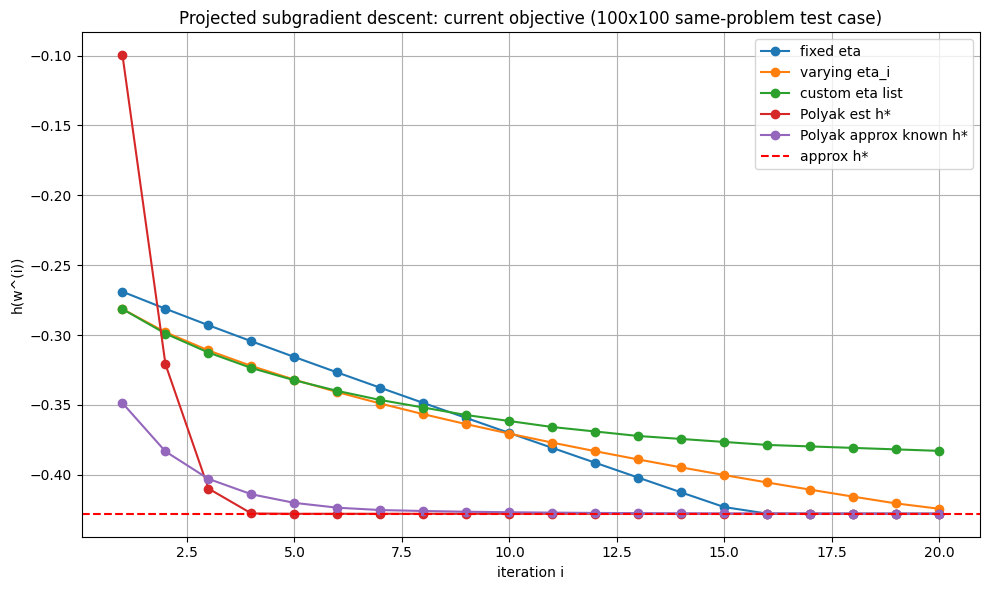

In [22]:
import matplotlib.pyplot as plt

label_map = {
    "fixed eta": "fixed eta",
    "varying eta_i": "varying eta_i",
    "custom eta list": "custom eta list",
    "Polyak eta_i (estimated h*)": "Polyak est h*",
    "Polyak eta_i (approx known h*)": "Polyak approx known h*"
}

plt.figure(figsize=(10, 6))

for method_name, result in results_100.items():
    history = result["history"]
    iterations = [x["iteration"] for x in history]
    h_vals = [x["h(w)"] for x in history]
    plt.plot(iterations, h_vals, marker="o", label=label_map.get(method_name, method_name))

plt.axhline(y=h_star_approx, color="red", linestyle="--", label="approx h*")
plt.xlabel("iteration i")
plt.ylabel("h(w^(i))")
plt.title("Projected subgradient descent: current objective (100x100 same-problem test case)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# $1000 \times 1000$

## Setup

In [23]:
import torch
import math
import matplotlib.pyplot as plt

# =========================================================
# 1000x1000 SAME-PROBLEM TEST CASE
# =========================================================
dtype = torch.float64
n = 1000

P = make_random_row_stochastic_matrix(n, seed=42)
Q = make_pair_swap_Q(n)
I = torch.eye(n, dtype=dtype)

M1 = P
M2 = 0.5 * (P + I)
M3 = 0.25 * P + 0.75 * I
M4 = 0.75 * P + 0.25 * I
M_list_1000 = [M1, M2, M3, M4]

pi = torch.ones(n, dtype=dtype) / n
w_init = torch.ones(4, dtype=dtype) / 4

# ---------------------------------------------------------
# Approximate h* for THIS SAME 1000x1000 problem
# ---------------------------------------------------------
T_ref_1000 = 500
eta_ref_1000 = lambda i: 0.2 / (i ** 0.5)

w_ref_final_1000, w_ref_avg_1000, history_ref_1000 = projected_subgradient_descent_urops(
    w_init=w_init,
    M_list=M_list_1000,
    Q=Q,
    pi=pi,
    n_iter=T_ref_1000,
    eta_schedule=eta_ref_1000,
    verbose=False
)

h_star_approx_1000 = min(x["h(w)"] for x in history_ref_1000)

print("Approximate h* (1000x1000) =", h_star_approx_1000)

Approximate h* (1000x1000) = -0.45339776532227705


In [24]:
# ---------------------------------------------------------
# Run all methods on the SAME 1000x1000 problem
# ---------------------------------------------------------
n_iter_1000 = 20
results_1000 = {}

## Case 1: Fixed $\eta$

In [25]:
w_final, w_avg, history = projected_subgradient_descent_urops(
    w_init=w_init,
    M_list=M_list_1000,
    Q=Q,
    pi=pi,
    n_iter=n_iter_1000,
    eta=0.10,
    verbose=False
)
results_1000["fixed eta"] = {"w_final": w_final, "w_avg": w_avg, "history": history}

## Case 2: Varying $\eta_{i}$

In [26]:
# Case 2: varying eta_i
eta_schedule_fn_1000 = lambda i: 0.2 / (i ** 0.5)

w_final, w_avg, history = projected_subgradient_descent_urops(
    w_init=w_init,
    M_list=M_list_1000,
    Q=Q,
    pi=pi,
    n_iter=n_iter_1000,
    eta_schedule=eta_schedule_fn_1000,
    verbose=False
)
results_1000["varying eta_i"] = {"w_final": w_final, "w_avg": w_avg, "history": history}

## Case 3: Custom $\eta$ list

In [27]:
eta_list_1000 = [
    0.20, 0.15, 0.12, 0.10, 0.08,
    0.07, 0.06, 0.05, 0.05, 0.04,
    0.04, 0.03, 0.03, 0.02, 0.02,
    0.02, 0.01, 0.01, 0.01, 0.01
]

w_final, w_avg, history = projected_subgradient_descent_urops(
    w_init=w_init,
    M_list=M_list_1000,
    Q=Q,
    pi=pi,
    n_iter=n_iter_1000,
    eta_schedule=eta_list_1000,
    verbose=False
)
results_1000["custom eta list"] = {"w_final": w_final, "w_avg": w_avg, "history": history}

## Case 4: Polyak's step length with estimated $h^{*}$

In [28]:
gamma_fn_1000 = lambda i: 1.0 / i

w_final, w_avg, history = projected_subgradient_descent_urops_polyak(
    w_init=w_init,
    M_list=M_list_1000,
    Q=Q,
    pi=pi,
    n_iter=n_iter_1000,
    gamma_schedule=gamma_fn_1000,
    verbose=False
)
results_1000["Polyak eta_i (estimated h*)"] = {"w_final": w_final, "w_avg": w_avg, "history": history}

## Case 5: Polyak's step length with approximately known $h^{*}$

In [29]:
w_final, w_avg, history = projected_subgradient_descent_urops_polyak(
    w_init=w_init,
    M_list=M_list_1000,
    Q=Q,
    pi=pi,
    n_iter=n_iter_1000,
    h_star=h_star_approx_1000,
    verbose=False
)
results_1000["Polyak eta_i (approx known h*)"] = {"w_final": w_final, "w_avg": w_avg, "history": history}

In [30]:
for method_name, result in results_1000.items():
    print(f"\n=== {method_name} ===")
    print("w_final =", result["w_final"])
    print("w_avg   =", result["w_avg"])
    print("last h  =", result["history"][-1]["h(w)"])


=== fixed eta ===
w_final = tensor([0.5938, 0.0000, 0.4062, 0.0000], dtype=torch.float64)
w_avg   = tensor([0.4831, 0.0857, 0.3471, 0.0841], dtype=torch.float64)
last h  = -0.4533559127671127

=== varying eta_i ===
w_final = tensor([0.5881, 0.0000, 0.4119, 0.0000], dtype=torch.float64)
w_avg   = tensor([0.4871, 0.0851, 0.3470, 0.0808], dtype=torch.float64)
last h  = -0.45322728632443077

=== custom eta list ===
w_final = tensor([0.5205, 0.0624, 0.3640, 0.0532], dtype=torch.float64)
w_avg   = tensor([0.4617, 0.1057, 0.3291, 0.1035], dtype=torch.float64)
last h  = -0.4133040841049382

=== Polyak eta_i (estimated h*) ===
w_final = tensor([0.5994, 0.0000, 0.4006, 0.0000], dtype=torch.float64)
w_avg   = tensor([6.4773e-01, 6.3838e-04, 3.5163e-01, 0.0000e+00], dtype=torch.float64)
last h  = -0.45339776531714615

=== Polyak eta_i (approx known h*) ===
w_final = tensor([5.9660e-01, 2.5399e-04, 4.0314e-01, 0.0000e+00], dtype=torch.float64)
w_avg   = tensor([0.5813, 0.0162, 0.3890, 0.0135], dty

## Plots

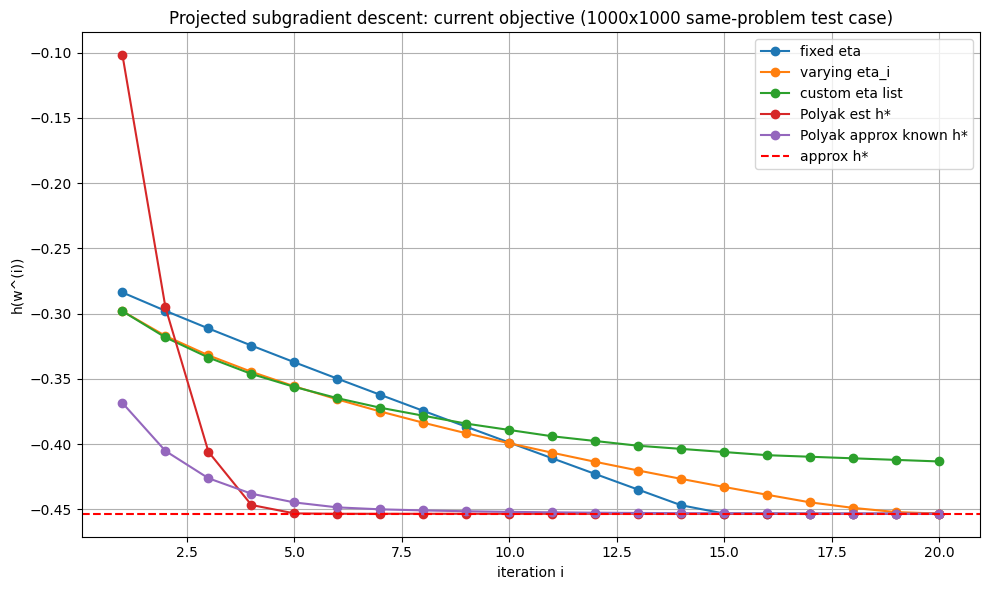

In [31]:
# ---------------------------------------------------------
# Plot current objective
# ---------------------------------------------------------
label_map = {
    "fixed eta": "fixed eta",
    "varying eta_i": "varying eta_i",
    "custom eta list": "custom eta list",
    "Polyak eta_i (estimated h*)": "Polyak est h*",
    "Polyak eta_i (approx known h*)": "Polyak approx known h*"
}

plt.figure(figsize=(10, 6))

for method_name, result in results_1000.items():
    history = result["history"]
    iterations = [x["iteration"] for x in history]
    h_vals = [x["h(w)"] for x in history]
    plt.plot(iterations, h_vals, marker="o", label=label_map.get(method_name, method_name))

plt.axhline(y=h_star_approx_1000, color="red", linestyle="--", label="approx h*")
plt.xlabel("iteration i")
plt.ylabel("h(w^(i))")
plt.title("Projected subgradient descent: current objective (1000x1000 same-problem test case)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()